# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [3]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [7]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df["Exited"] == 0]
df_1 = df[df["Exited"] == 1]

print(df_0.shape)
print(df_1.shape)

(7963, 14)
(2037, 14)


## Hypothesis 1: Age

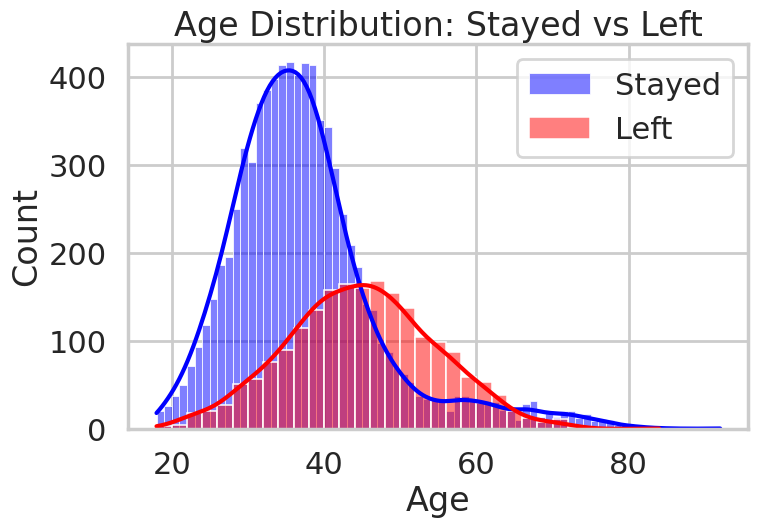

In [9]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

sns.histplot(df_0["Age"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1["Age"], color="red", label="Left", kde=True)

plt.title("Age Distribution: Stayed vs Left")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

In [10]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
age_mean = df_0["Age"].mean()
age_std = df_0["Age"].std()

print("Mean Age:", round(age_mean, 2))
print("Standard Deviation:", round(age_std, 2))

Mean Age: 37.41
Standard Deviation: 10.13


In [11]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
age_mean_left = df_1["Age"].mean()
age_std_left = df_1["Age"].std()

print("Mean Age:", round(age_mean_left, 2))
print("Standard Deviation:", round(age_std_left, 2))

Mean Age: 44.84
Standard Deviation: 9.76


In [13]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
from scipy import stats

t_stat, p_value = stats.ttest_ind(df_0["Age"], df_1["Age"], equal_var=False)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -30.4192
P-value: 0.0


### Using Bootstrapping

In [14]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
import numpy as np

def bs_choice(data, func, size):
    bs_s = np.empty(size)

    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)

    return bs_s

In [15]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
# Difference in observed means
empirical_diff_means = np.mean(df_1["Age"]) - np.mean(df_0["Age"])

# Overall mean age
mean_age = np.mean(df["Age"])

# Shift both groups to the same overall mean
age_0_shifted = df_0["Age"] -(df_0[" np.meanAge"]) + mean_age
age_1_shifted = df_1["Age"] - np.mean(df_1["Age"]) + mean_age

print("Difference in means:", round(empirical_diff_means, 2))
print("Overall mean age:", round(mean_age, 2))

Difference in means: 7.43
Overall mean age: 38.92


In [16]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
# Bootstrap samples of the mean
bs_age_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_age_1 = bs_choice(age_1_shifted, np.mean, 10000)

# Difference between bootstrap means
bs_diff = bs_age_1 - bs_age_0

print("Bootstrap std - Stayed:", round(np.std(bs_age_0), 4))
print("Bootstrap std - Left:", round(np.std(bs_age_1), 4))
print("Bootstrap std - Difference:", round(np.std(bs_diff), 4))

Bootstrap std - Stayed: 0.1134
Bootstrap std - Left: 0.216
Bootstrap std - Difference: 0.2454


In [17]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.

# Two-sided p-value
p_value = np.mean(np.abs(bs_diff) >= np.abs(empirical_diff_means))

print("Bootstrap p-value:", p_value)

Bootstrap p-value: 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis because the p-value is much smaller than 0.05.

This means there is a statistically significant difference between the ages of customers who stayed and customers who left the bank.

## Hypothesis 2: Credit Score

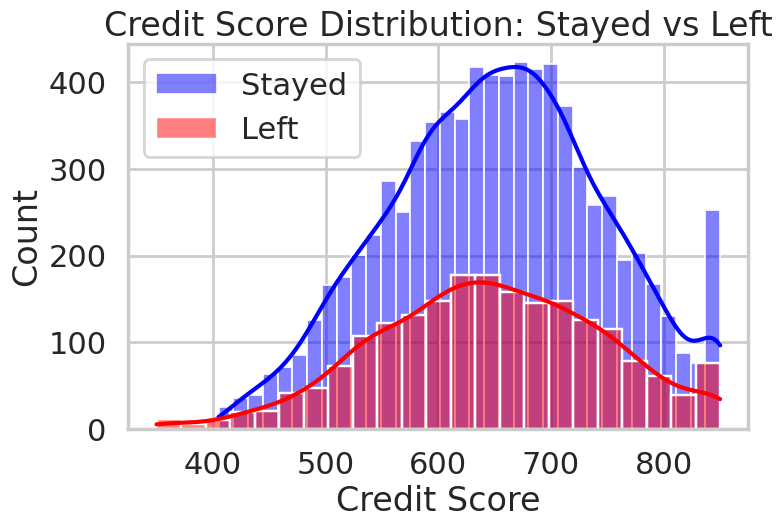

In [18]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

plt.figure(figsize=(8,5))

sns.histplot(df_0["CreditScore"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1["CreditScore"], color="red", label="Left", kde=True)

plt.title("Credit Score Distribution: Stayed vs Left")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.legend()

plt.show()

In [19]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

t_stat, p_value = stats.ttest_ind(
    df_0["CreditScore"],
    df_1["CreditScore"],
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: 2.6347
P-value: 0.0085


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis because the p-value (0.0085) is smaller than 0.05.

This indicates a statistically significant difference in CreditScore between customers who stayed and customers who left the bank.

## Hypothesis 3: Balance

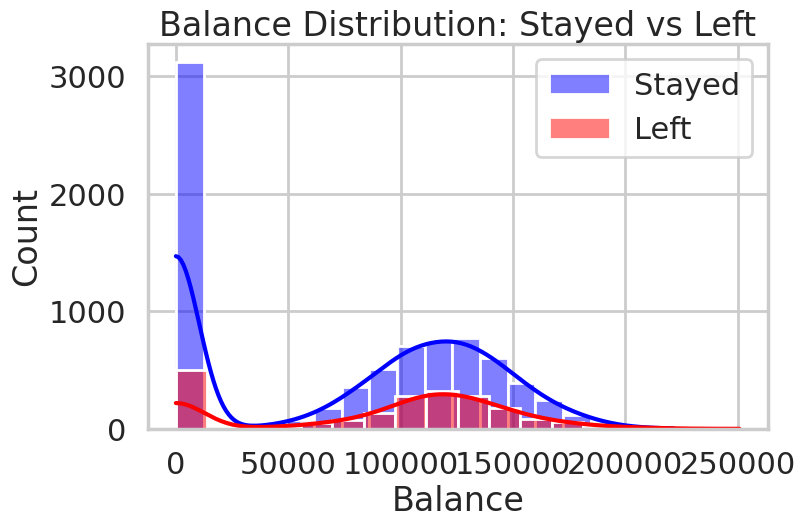

In [20]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

plt.figure(figsize=(8,5))

sns.histplot(df_0["Balance"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1["Balance"], color="red", label="Left", kde=True)

plt.title("Balance Distribution: Stayed vs Left")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.legend()

plt.show()

In [21]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

t_stat, p_value = stats.ttest_ind(
    df_0["Balance"],
    df_1["Balance"],
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -12.4713
P-value: 0.0


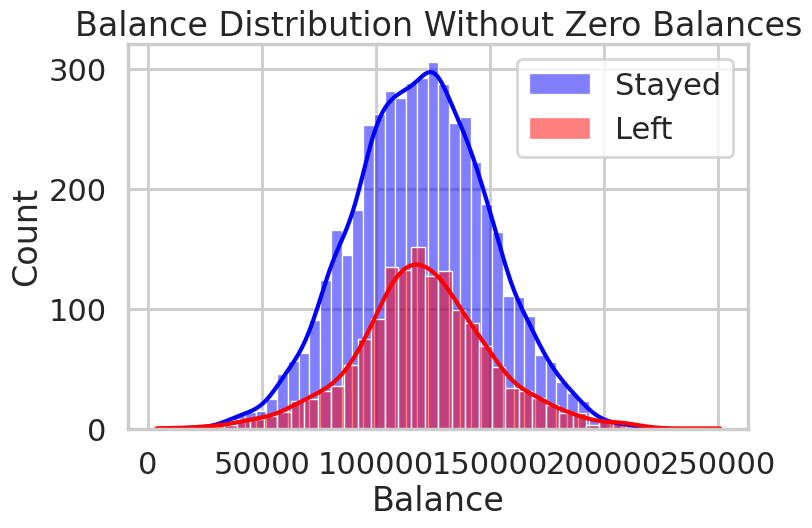

In [22]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

plt.figure(figsize=(8,5))

sns.histplot(df_0[df_0["Balance"] > 0]["Balance"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1[df_1["Balance"] > 0]["Balance"], color="red", label="Left", kde=True)

plt.title("Balance Distribution Without Zero Balances")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.legend()

plt.show()

In [23]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

t_stat, p_value = stats.ttest_ind(
    df_0[df_0["Balance"] > 0]["Balance"],
    df_1[df_1["Balance"] > 0]["Balance"],
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -1.3605
P-value: 0.1738


## Conclusion

Do we reject the Null Hypothesis ? Why ?

Fail to reject the Null Hypothesis.

The p-value (0.1738) is greater than 0.05, so there is no statistically significant difference in Balance between customers who stayed and customers who left when zero balances are excluded.

## Hypothesis 4: Estimated Salary

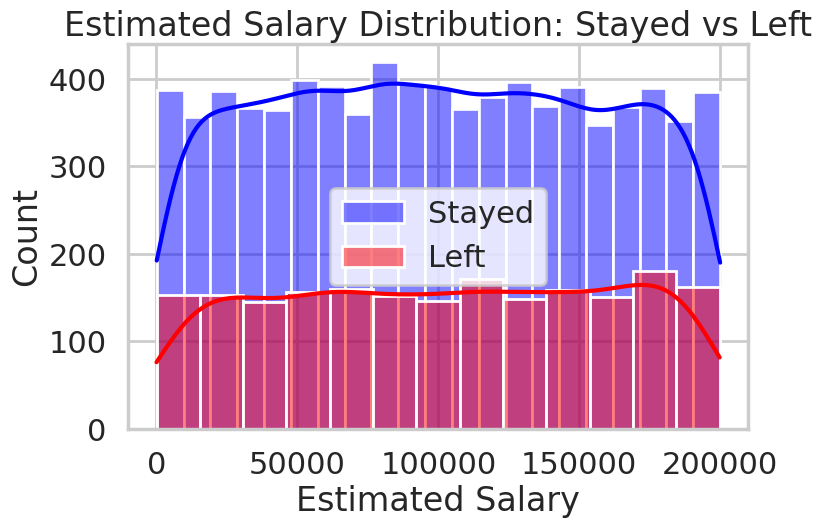

In [24]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(8,5))

sns.histplot(df_0["EstimatedSalary"], color="blue", label="Stayed", kde=True)
sns.histplot(df_1["EstimatedSalary"], color="red", label="Left", kde=True)

plt.title("Estimated Salary Distribution: Stayed vs Left")
plt.xlabel("Estimated Salary")
plt.ylabel("Count")
plt.legend()

plt.show()

In [25]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat, p_value = stats.ttest_ind(
    df_0["EstimatedSalary"],
    df_1["EstimatedSalary"],
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: -1.2034
P-value: 0.2289


Using Bootstrapping

In [29]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
# Difference in observed means
empirical_diff_means_salary = np.mean(df_1["EstimatedSalary"]) - np.mean(df_0["EstimatedSalary"])

# Overall mean salary
mean_salary = np.mean(df["EstimatedSalary"])

# Shift both groups to the same overall mean
salary_0_shifted = df_0["EstimatedSalary"] - np.mean(df_0["EstimatedSalary"]) + mean_salary
salary_1_shifted = df_1["EstimatedSalary"] - np.mean(df_1["EstimatedSalary"]) + mean_salary

print("Difference in means:", round(empirical_diff_means_salary, 2))
print("Overall mean salary:", round(mean_salary, 2))

Difference in means: 1727.29
Overall mean salary: 100090.24


In [30]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
# Bootstrap sample means
bs_salary_0 = bs_choice(salary_0_shifted, np.mean, 10000)
bs_salary_1 = bs_choice(salary_1_shifted, np.mean, 10000)

# Difference between bootstrap means
bs_salary_diff = bs_salary_1 - bs_salary_0

print("Bootstrap mean - Stayed:", round(np.mean(bs_salary_0), 2))
print("Bootstrap mean - Left:", round(np.mean(bs_salary_1), 2))
print("Bootstrap mean difference:", round(np.mean(bs_salary_diff), 2))

Bootstrap mean - Stayed: 100098.4
Bootstrap mean - Left: 100102.32
Bootstrap mean difference: 3.93


In [31]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
# Two-sided bootstrap p-value
p_value_salary = np.mean(
    np.abs(bs_salary_diff) >= np.abs(empirical_diff_means_salary)
)

print("Bootstrap p-value:", p_value_salary)

Bootstrap p-value: 0.2291


### Conclusion
Do we reject the Null Hypothesis ? Why ?

fail to reject the Null Hypothesis.

## Final Conclusion
What will be the most helpful feature in predicting churning?
